In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import keras
from keras.layers import Input, Dense, Lambda
from keras.models import Model
import tensorflow as tf
from tensorflow.keras import layers
import joblib
from numpy import genfromtxt
import os
import gc

2026-03-05 08:26:29.984725: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-03-05 08:26:29.984782: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-03-05 08:26:30.176559: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-03-05 08:26:30.561280: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
scaled_input_ohc_train = genfromtxt('ohc700_train_robustscaler.csv', delimiter=',')
scaled_input_ohc_test = genfromtxt('ohc700_test_robustscaler.csv', delimiter=',')

scaled_input_sst_train = genfromtxt('sst_train_robustscaler.csv', delimiter=',')
scaled_input_sst_test = genfromtxt('sst_test_robustscaler.csv', delimiter=',')

scaled_input_olr_train = genfromtxt('olr_train_robustscaler.csv', delimiter=',')
scaled_input_olr_test = genfromtxt('olr_test_robustscaler.csv', delimiter=',')

In [3]:
# load netcdf files with time component 
sequential_input_ohc_train = xr.load_dataarray('ohc700_train_robustscaler.nc')
sequential_input_ohc_test = xr.load_dataarray('ohc700_test_robustscaler.nc')

sequential_input_olr_train = xr.load_dataarray('olr_train_robustscaler.nc')
sequential_input_olr_test = xr.load_dataarray('olr_test_robustscaler.nc')

sequential_input_sst_train = xr.load_dataarray('sst_train_robustscaler.nc')
sequential_input_sst_test = xr.load_dataarray('sst_test_robustscaler.nc')

In [4]:
# sanity checks
print(scaled_input_sst_train.shape,
     scaled_input_sst_test.shape,
     scaled_input_ohc_train.shape,
     scaled_input_ohc_test.shape,
     scaled_input_olr_train.shape,
     scaled_input_olr_test.shape)

(4800, 2968) (1200, 2968) (4800, 2960) (1200, 2960) (4800, 2662) (1200, 2662)


## build autoencoder

In [5]:
# set random seed
keras.utils.set_random_seed(1)

In [6]:
# check input shape for sst
input_shape_sst = scaled_input_sst_train.shape[1]
print(input_shape_sst)

# check input shape for ohc
input_shape_ohc = scaled_input_ohc_train.shape[1]
print(input_shape_ohc)

# check input shape for olr
input_shape_olr = scaled_input_olr_train.shape[1]
print(input_shape_olr)

2968
2960
2662


In [7]:
# define latent space (going to be 20 here)
latent_dim = 20

In [8]:
# sst input
input_sst = Input(shape=(np.int64(input_shape_sst),), name='input_sst')
print(input_sst.shape)

# add 2 dense layers
encoded_sst_layer1 = Dense(400, activation='tanh')(input_sst)
encoded_sst_layer2 = Dense(250, activation='tanh')(encoded_sst_layer1)
encoded_sst_layer3 = Dense(180, activation='tanh')(encoded_sst_layer2)
encoded_sst_layer4 = Dense(100, activation='tanh')(encoded_sst_layer3)
encoded_sst_layer5 = Dense(30, activation='tanh')(encoded_sst_layer4)

# ohc input
input_ohc = Input(shape=(np.int64(input_shape_ohc),), name='input_ohc')
print(input_ohc.shape)

# add 2 dense layers (again)
encoded_ohc_layer1 = Dense(400, activation='tanh')(input_ohc)
encoded_ohc_layer2 = Dense(250, activation='tanh')(encoded_ohc_layer1)
encoded_ohc_layer3 = Dense(180, activation='tanh')(encoded_ohc_layer2)
encoded_ohc_layer4 = Dense(100, activation='tanh')(encoded_ohc_layer3)
encoded_ohc_layer5 = Dense(30, activation='tanh')(encoded_ohc_layer4)

# olr input
input_olr = Input(shape=(np.int64(input_shape_olr),),
                          name='input_olr')
print(input_olr.shape)

# add 2 dense layers (again)
encoded_olr_layer1 = Dense(400, activation='tanh')(input_olr)
encoded_olr_layer2 = Dense(250, activation='tanh')(encoded_olr_layer1)
encoded_olr_layer3 = Dense(180, activation='tanh')(encoded_olr_layer2)
encoded_olr_layer4 = Dense(100, activation='tanh')(encoded_olr_layer3)
encoded_olr_layer5 = Dense(30, activation='tanh')(encoded_olr_layer4)

(None, 2968)


2026-03-05 08:27:41.212266: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


(None, 2960)
(None, 2662)


In [9]:
# concatenate inputs before passing through latent space
encoder_output_concat = keras.layers.Concatenate()([encoded_sst_layer5,
                        encoded_ohc_layer5,
                        encoded_olr_layer5]
                      )

In [10]:
# create latent space with z_mean and z_log_var

z_mean = Dense(latent_dim, name='z_mean')(encoder_output_concat)
z_log_var = Dense(latent_dim, name='z_log_var')(encoder_output_concat)

In [11]:
# reparameterization trick 
# "we now treat random sampling as a noise term"
# the standard normal is a gaussian distribution with mean mu = 0 and sigma = 1
# https://medium.com/@weidagang/demystifying-neural-networks-variational-autoencoders-6a44e75d0271

def sampling(args):
    z_mean, z_log_var = args
    
    epsilon = keras.backend.random_normal(shape=keras.backend.shape(z_mean), mean=0., stddev=1.)
    return z_mean + keras.backend.exp(z_log_var / 2) * epsilon

z = Lambda(sampling, output_shape=(latent_dim,), name='z_sampling')([z_mean, z_log_var])

In [12]:
# build decoder for each variable from the latent space
# sst
decoded1_sst = Dense(30, activation='tanh')(z)
decoded2_sst = Dense(100, activation='tanh')(decoded1_sst)
decoded3_sst = Dense(180, activation='tanh')(decoded2_sst)
decoded4_sst = Dense(250, activation='tanh')(decoded3_sst)
decoded5_sst = Dense(400, activation='tanh')(decoded4_sst)
output_sst = Dense(np.int64(input_shape_sst), activation='linear', name='output_sst')(decoded5_sst)
print(output_sst.shape)

# build decoder for each variable from the latent space
# ohc
decoded1_ohc = Dense(30, activation='tanh')(z)
decoded2_ohc = Dense(100, activation='tanh')(decoded1_ohc)
decoded3_ohc = Dense(180, activation='tanh')(decoded2_ohc)
decoded4_ohc = Dense(250, activation='tanh')(decoded3_ohc)
decoded5_ohc = Dense(400, activation='tanh')(decoded4_ohc)
output_ohc = Dense(np.int64(input_shape_ohc), activation='linear', name='output_ohc')(decoded5_ohc)
print(output_ohc.shape)

# build decoder for each variable from the latent space
# olr
decoded1_olr = Dense(30, activation='tanh')(z)
decoded2_olr = Dense(100, activation='tanh')(decoded1_olr)
decoded3_olr = Dense(180, activation='tanh')(decoded2_olr)
decoded4_olr = Dense(250, activation='tanh')(decoded3_olr)
decoded5_olr = Dense(400, activation='tanh')(decoded4_olr)
output_olr = Dense(
    np.int64(input_shape_olr), activation='linear', name='output_olr')(decoded5_olr)
print(output_olr.shape)

(None, 2968)
(None, 2960)
(None, 2662)


In [13]:
# final VAE model
vae = Model(inputs=[input_sst, input_ohc, input_olr], 
            outputs= [output_sst, output_ohc, output_olr]
                 )

In [14]:
vae.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_sst (InputLayer)      [(None, 2968)]               0         []                            
                                                                                                  
 input_ohc (InputLayer)      [(None, 2960)]               0         []                            
                                                                                                  
 input_olr (InputLayer)      [(None, 2662)]               0         []                            
                                                                                                  
 dense (Dense)               (None, 400)                  1187600   ['input_sst[0][0]']           
                                                                                              

In [15]:
# create class for custom losses
# this will return losses of each variable during training
# can also define weights here

class VAELossLayer(layers.Layer):
    def __init__(self, input_shape_sst, input_shape_ohc, input_shape_olr, kl_weight=0.0005, **kwargs):
        super(VAELossLayer, self).__init__(**kwargs)
        self.input_shape_sst = input_shape_sst
        self.input_shape_ohc = input_shape_ohc
        self.input_shape_olr = input_shape_olr
        self.kl_weight = kl_weight

    def call(self, inputs):
        input_sst, input_ohc, input_olr, output_sst, output_ohc, output_olr, z_mean, z_log_var = inputs
        #print(inputs.shape)

        # Reconstruction loss
        reconstruction_loss_sst = keras.losses.mse(input_sst, output_sst)# * self.input_shape_sst
        reconstruction_loss_ohc = keras.losses.mse(input_ohc, output_ohc)# * self.input_shape_ohc
        reconstruction_loss_olr = keras.losses.mse(input_olr, output_olr)# * self.input_shape_olr

        self.add_metric(reconstruction_loss_sst, name="sst_loss", aggregation="mean")
        self.add_metric(reconstruction_loss_ohc, name="ohc_loss", aggregation="mean")
        self.add_metric(reconstruction_loss_olr, name="olr_loss", aggregation="mean")
        
        reconstruction_loss = reconstruction_loss_sst + reconstruction_loss_ohc + reconstruction_loss_olr

        kl_loss = 1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var)
        kl_loss = tf.reduce_sum(kl_loss, axis=-1) * -0.5
        kl_loss = kl_loss * self.kl_weight

        # Total loss
        total_loss = tf.reduce_mean(reconstruction_loss) + tf.reduce_mean(kl_loss)
        self.add_loss(total_loss)
        self.add_metric(kl_loss, name="kl_loss", aggregation="mean")

        return output_sst, output_ohc, output_olr, total_loss, kl_loss, reconstruction_loss_sst, reconstruction_loss_ohc, reconstruction_loss_olr  # including kl_loss as output

In [16]:
# add the custom loss layer
outputs = VAELossLayer(input_shape_sst, input_shape_ohc, input_shape_olr)([
    input_sst, input_ohc, input_olr, output_sst, output_ohc, output_olr, z_mean, z_log_var
])

In [17]:
# define VAE model
vae = keras.Model(inputs=[input_sst, input_ohc, input_olr], outputs=outputs)

opt = keras.optimizers.Adam(learning_rate=0.0003)
vae.compile(optimizer=opt,
            run_eagerly=True)

In [18]:
# fit the model
vae_model_history = vae.fit(
    x=[scaled_input_sst_train, scaled_input_ohc_train, scaled_input_olr_train],
    #y=[scaled_input_sst_train, scaled_input_ohc_train, scaled_input_olr_train],
    y=None,  # `y` is None because the loss is calculated within the model
    epochs=150,
    batch_size=256,
    validation_split=0.25
)

Epoch 1/150
15/15 [==============================] - 4s 263ms/step - loss: 2.5540 - sst_loss: 0.8168 - ohc_loss: 0.7057 - olr_loss: 1.0621 - kl_loss: 0.0099 - val_loss: 2.1870 - val_sst_loss: 0.6010 - val_ohc_loss: 0.5652 - val_olr_loss: 0.9930 - val_kl_loss: 0.0131
Epoch 2/150
15/15 [==============================] - 4s 279ms/step - loss: 1.9241 - sst_loss: 0.5052 - ohc_loss: 0.5099 - olr_loss: 0.8920 - kl_loss: 0.0115 - val_loss: 1.8180 - val_sst_loss: 0.4693 - val_ohc_loss: 0.4679 - val_olr_loss: 0.8587 - val_kl_loss: 0.0130
Epoch 3/150
15/15 [==============================] - 5s 303ms/step - loss: 1.6735 - sst_loss: 0.4228 - ohc_loss: 0.4289 - olr_loss: 0.8043 - kl_loss: 0.0133 - val_loss: 1.6371 - val_sst_loss: 0.4032 - val_ohc_loss: 0.4023 - val_olr_loss: 0.8101 - val_kl_loss: 0.0140
Epoch 4/150
15/15 [==============================] - 5s 309ms/step - loss: 1.5275 - sst_loss: 0.3730 - ohc_loss: 0.3787 - olr_loss: 0.7698 - kl_loss: 0.0143 - val_loss: 1.5529 - val_sst_loss: 0.3699 

## items to define 

In [20]:
# decoder model
decoder_model = Model(inputs=[z],
                     outputs=[output_sst,
                              output_ohc,
                              output_olr]
                     )
decoder_model.summary()

Model: "model_2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 20)]                 0         []                            
                                                                                                  
 dense_15 (Dense)            (None, 30)                   630       ['input_1[0][0]']             
                                                                                                  
 dense_20 (Dense)            (None, 30)                   630       ['input_1[0][0]']             
                                                                                                  
 dense_25 (Dense)            (None, 30)                   630       ['input_1[0][0]']             
                                                                                            

In [21]:
scaler_sst = joblib.load('scaler_sst.pkl')
scaler_ohc = joblib.load('scaler_ohc700.pkl')
scaler_olr = joblib.load('scaler_olr.pkl')

In [22]:
# indices can be loaded anytime and used for reconstruction
sst_yindx = np.load('sst_yindx.npy')
sst_xindx = np.load('sst_xindx.npy')

ohc_yindx = np.load('ohc_yindx.npy')
ohc_xindx = np.load('ohc_xindx.npy')

olr_yindx = np.load('olr_yindx.npy')
olr_xindx = np.load('olr_xindx.npy')

In [23]:
n_points = 6000
latent_dim = 20
sweep_range = np.linspace(-3, 3, n_points)

In [24]:
ocn = xr.open_dataset('ocean.nc')
atm = xr.open_dataset('atmosphere.nc')

In [25]:
ocn_lat = ocn.lat.values
ocn_lon = ocn.lon.values

atm_lat = atm.lat.values
atm_lon = atm.lon.values

In [26]:
def reconstruct_grid(pred_1d, y_indx, x_indx):
    n_samples = pred_1d.shape[0]
    pred_grid = np.full((n_samples, 20, 150), np.nan)
    pred_grid[:, y_indx, x_indx] = pred_1d
    return pred_grid

def reconstruct_grid_olr(pred_1d, y_indx, x_indx):
    n_samples = pred_1d.shape[0]
    pred_grid = np.full((n_samples, 22, 121), np.nan)
    pred_grid[:, y_indx, x_indx] = pred_1d
    return pred_grid

## slope maps sst -- using polyfit

In [27]:
def generate_sst_slope_maps(
    decoder_model,
    scaler_sst,
    sst_yindx,
    sst_xindx,
    sweep_range,
    latent_dim,
    n_points
):

    # ocean grid size
    ny, nx = 20, 150
    slope_maps = np.zeros((latent_dim, ny, nx))

    for ld in range(latent_dim):
        print(f"Computing SST slope for latent dimension {ld}")

        # idealized latent traversal
        # filled with zero vector to isloate each dimensions
        latent_sweep = np.zeros((n_points, latent_dim))
        latent_sweep[:, ld] = sweep_range

        # only interested in sst here
        recon_sst, _, _ = decoder_model.predict(latent_sweep, verbose=0)
        flat_sst = scaler_sst.inverse_transform(
            recon_sst.reshape(n_points, -1)
        )

        # reshape to ocean grid
        sst_grid = reconstruct_grid(flat_sst, sst_yindx, sst_xindx)

        # regress at each grid cell
        for y in range(ny):
            for x in range(nx):
                if np.all(np.isnan(sst_grid[:, y, x])):
                    continue
                slope, _ = np.polyfit(sweep_range, sst_grid[:, y, x], 1)
                slope_maps[ld, y, x] = slope

    return slope_maps

In [28]:
slope_maps_sst = generate_sst_slope_maps(decoder_model=decoder_model,
                                         scaler_sst=scaler_sst,
                                         sst_yindx=sst_yindx,
                                         sst_xindx=sst_xindx,
                                         sweep_range=sweep_range,
                                         latent_dim=latent_dim,
                                         n_points=n_points
                                        )

Computing SST slope for latent dimension 0
Computing SST slope for latent dimension 1
Computing SST slope for latent dimension 2
Computing SST slope for latent dimension 3
Computing SST slope for latent dimension 4
Computing SST slope for latent dimension 5
Computing SST slope for latent dimension 6
Computing SST slope for latent dimension 7
Computing SST slope for latent dimension 8
Computing SST slope for latent dimension 9
Computing SST slope for latent dimension 10
Computing SST slope for latent dimension 11
Computing SST slope for latent dimension 12
Computing SST slope for latent dimension 13
Computing SST slope for latent dimension 14
Computing SST slope for latent dimension 15
Computing SST slope for latent dimension 16
Computing SST slope for latent dimension 17
Computing SST slope for latent dimension 18
Computing SST slope for latent dimension 19


In [29]:
# check if regrid worked
slope_maps_sst.shape

(20, 20, 150)

In [32]:
def plot_sst_slope_maps(slope_maps_sst, lon, lat):

    n_ld = slope_maps_sst.shape[0]
    ncols = 3
    nrows = int(np.ceil(n_ld / ncols))

    fig, axs = plt.subplots(
        nrows, ncols,
        figsize=(6 * ncols, 2.2 * nrows),
        sharex=True, sharey=True
    )
    axs = axs.flatten()

    vmax = 0.75
    vmin = -0.75
    extent = [lon.min(), lon.max(), lat.min(), lat.max()]

    # Define a subset of longitude ticks you want displayed
    #tick_lons = np.array([130, 160, 190, 220, 250, 280])
    tick_lons = np.array([130, 180, 230, 280])
    tick_labels_lon = []
    for lon_val in tick_lons:
        if lon_val <= 180:
            tick_labels_lon.append(f"{int(lon_val)}°E")
        else:
            tick_labels_lon.append(f"{360 - int(lon_val)}°W")  # 280 → 80°W

    # Define a subset of latitude ticks
    lat_ticks = np.array([-10, 0, 10])  # e.g., -10, -5, 0, 5, 10
    tick_labels_lat = []
    for lat_val in lat_ticks:
        if lat_val < 0:
            tick_labels_lat.append(f"{abs(lat_val)}°S")
        elif lat_val > 0:
            tick_labels_lat.append(f"{lat_val}°N")
        else:
            tick_labels_lat.append("0°")

    for ld in range(n_ld):
        ax = axs[ld]
        im = ax.imshow(
            slope_maps_sst[ld],
            origin='lower',
            extent=extent,
            cmap='RdBu_r',
            vmin=vmin,
            vmax=vmax,
            aspect='auto'
        )
        ax.set_title(f'LD {ld+1}', fontsize=18)
        ax.tick_params(axis='both', labelsize=18)
        ax.set_xticklabels(tick_labels_lon, ha='center', rotation=45)  # rotate 45° and align right

        # Set the subset of ticks and custom labels
        ax.set_xticks(tick_lons)
        ax.set_xticklabels(tick_labels_lon)
        ax.set_yticks(lat_ticks)
        ax.set_yticklabels(tick_labels_lat)

    # turn off unused axes
    for ax in axs[n_ld:]:
        ax.axis('off')

    #adjust spacing
    plt.subplots_adjust(
        left=0.03, right=0.97, top=0.92, bottom=0.08,
        wspace=0.1, hspace=0.25
    )

    # horizontal colorbar under LD17
    ax_ld17 = axs[17]  # LD17
    pos = ax_ld17.get_position()  # Bbox in figure coordinates
    cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.085, pos.width, 0.025])  # slightly below
    cbar = fig.colorbar(im,
                        cax=cbar_ax,
                        orientation='horizontal',
                        extend='both',
                        shrink=0.8)
    cbar.set_label('∂SST / ∂z', fontsize=18)
    cbar.ax.tick_params(labelsize=14)


    fig.suptitle(
        'Linear SST Sensitivity to Latent Dimension Perturbations',
        fontsize=22,
        y=0.97
    )
    #plt.savefig('sst_sensitivity_0305.pdf', bbox_inches='tight')

    plt.show()

/glade/derecho/scratch/ewisinski/tmp/ipykernel_85128/1468901048.py:52: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(tick_labels_lon, ha='center', rotation=45)  # rotate 45° and align right


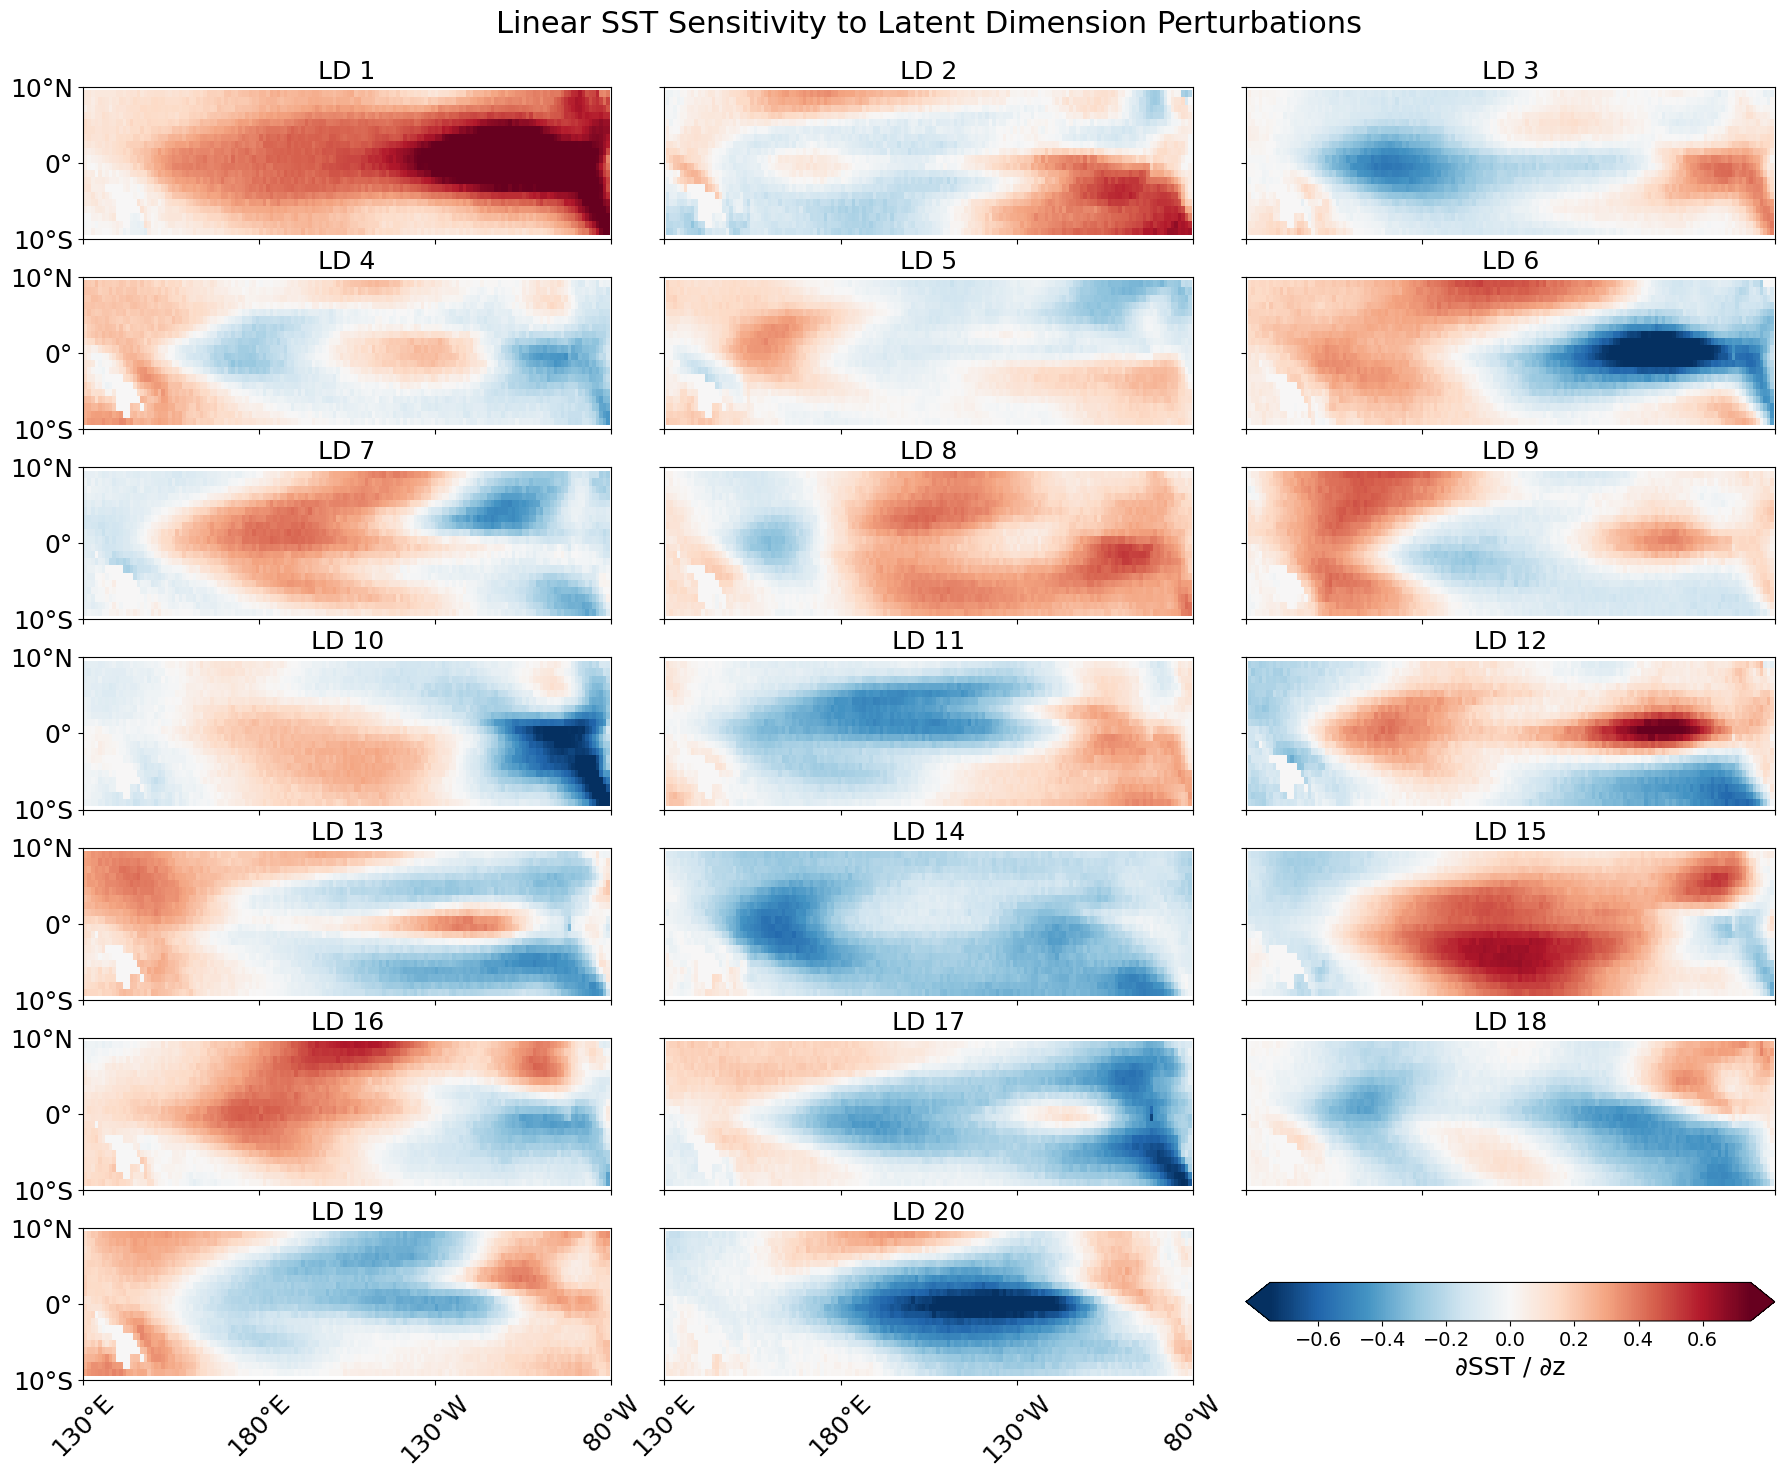

In [33]:
plot_sst_slope_maps(slope_maps_sst, lon=ocn_lon, lat=ocn_lat)

## ohc slope maps

In [34]:
def generate_ohc_slope_maps(
    decoder_model,
    scaler_ohc,
    ohc_yindx,
    ohc_xindx,
    sweep_range,
    latent_dim,
    n_points
):

    # ocean grid size
    ny, nx = 20, 150
    slope_maps = np.zeros((latent_dim, ny, nx))

    for ld in range(latent_dim):
        print(f"Computing OHC slope for latent dimension {ld}")

        # idealized latent traversal
        # filled with zero vector to isloate each dimensions
        latent_sweep = np.zeros((n_points, latent_dim))
        latent_sweep[:, ld] = sweep_range

        # only focused ohc here
        _, recon_ohc, _ = decoder_model.predict(latent_sweep, verbose=0)
        flat_ohc = scaler_ohc.inverse_transform(
            recon_ohc.reshape(n_points, -1)
        )

        # reshape to grid for clarity
        ohc_grid = reconstruct_grid(flat_ohc, ohc_yindx, ohc_xindx)

        # regress at each grid cell
        for y in range(ny):
            for x in range(nx):
                if np.all(np.isnan(ohc_grid[:, y, x])):
                    continue
                slope, _ = np.polyfit(sweep_range, ohc_grid[:, y, x], 1)
                slope_maps[ld, y, x] = slope

    return slope_maps

In [35]:
slope_maps_ohc = generate_ohc_slope_maps(decoder_model=decoder_model,
                                         scaler_ohc=scaler_ohc,
                                         ohc_yindx=ohc_yindx,
                                         ohc_xindx=ohc_xindx,
                                         sweep_range=sweep_range,
                                         latent_dim=latent_dim,
                                         n_points=n_points
                                        )

Computing OHC slope for latent dimension 0
Computing OHC slope for latent dimension 1
Computing OHC slope for latent dimension 2
Computing OHC slope for latent dimension 3
Computing OHC slope for latent dimension 4
Computing OHC slope for latent dimension 5
Computing OHC slope for latent dimension 6
Computing OHC slope for latent dimension 7
Computing OHC slope for latent dimension 8
Computing OHC slope for latent dimension 9
Computing OHC slope for latent dimension 10
Computing OHC slope for latent dimension 11
Computing OHC slope for latent dimension 12
Computing OHC slope for latent dimension 13
Computing OHC slope for latent dimension 14
Computing OHC slope for latent dimension 15
Computing OHC slope for latent dimension 16
Computing OHC slope for latent dimension 17
Computing OHC slope for latent dimension 18
Computing OHC slope for latent dimension 19


In [36]:
slope_maps_ohc.shape

(20, 20, 150)

In [39]:
def plot_ohc_slope_maps(slope_maps_ohc, lon, lat):

    n_ld = slope_maps_sst.shape[0]
    ncols = 3
    nrows = int(np.ceil(n_ld / ncols))

    fig, axs = plt.subplots(
        nrows, ncols,
        figsize=(6 * ncols, 2.2 * nrows),
        sharex=True, sharey=True
    )
    axs = axs.flatten()

    vmax = 0.95e9
    vmin = -0.95e9
    extent = [lon.min(), lon.max(), lat.min(), lat.max()]

    # Define a subset of longitude ticks you want displayed
    #tick_lons = np.array([130, 160, 190, 220, 250, 280])
    tick_lons = np.array([130, 180, 230, 280])
    tick_labels_lon = []
    for lon_val in tick_lons:
        if lon_val <= 180:
            tick_labels_lon.append(f"{int(lon_val)}°E")
        else:
            tick_labels_lon.append(f"{360 - int(lon_val)}°W")  # 280 → 80°W

    # Define a subset of latitude ticks
    lat_ticks = np.array([-10, 0, 10])  # e.g., -10, -5, 0, 5, 10
    tick_labels_lat = []
    for lat_val in lat_ticks:
        if lat_val < 0:
            tick_labels_lat.append(f"{abs(lat_val)}°S")
        elif lat_val > 0:
            tick_labels_lat.append(f"{lat_val}°N")
        else:
            tick_labels_lat.append("0°")

    for ld in range(n_ld):
        ax = axs[ld]
        im = ax.imshow(
            slope_maps_ohc[ld],
            origin='lower',
            extent=extent,
            cmap='coolwarm',
            vmin=vmin,
            vmax=vmax,
            aspect='auto'
        )
        ax.set_title(f'LD {ld+1}', fontsize=18)
        ax.tick_params(axis='both', labelsize=18)
        ax.set_xticklabels(tick_labels_lon, ha='center', rotation=45)  # rotate 45° and align right

        # Set the subset of ticks and custom labels
        ax.set_xticks(tick_lons)
        ax.set_xticklabels(tick_labels_lon)
        ax.set_yticks(lat_ticks)
        ax.set_yticklabels(tick_labels_lat)

    # turn off unused axes
    for ax in axs[n_ld:]:
        ax.axis('off')

    #adjust spacing
    plt.subplots_adjust(
        left=0.03, right=0.97, top=0.92, bottom=0.08,
        wspace=0.1, hspace=0.25
    )

    # --- Horizontal colorbar under LD17 ---
    ax_ld17 = axs[17]  # LD17
    pos = ax_ld17.get_position()  # Bbox in figure coordinates
    cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.085, pos.width, 0.025])  # slightly below
    cbar = fig.colorbar(im,
                        cax=cbar_ax,
                        orientation='horizontal',
                        extend='both',
                        shrink=0.8)
    cbar.set_label('∂OHC / ∂z', fontsize=18)
    cbar.ax.tick_params(labelsize=14)


    fig.suptitle(
        'Linear OHC Sensitivity to Latent Dimension Perturbations',
        fontsize=22,
        y=0.97
    )
    #plt.savefig('ohc_sensitivity_0305_coolwarm.pdf', bbox_inches='tight')

    plt.show()

/glade/derecho/scratch/ewisinski/tmp/ipykernel_85128/3646023654.py:52: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(tick_labels_lon, ha='center', rotation=45)  # rotate 45° and align right


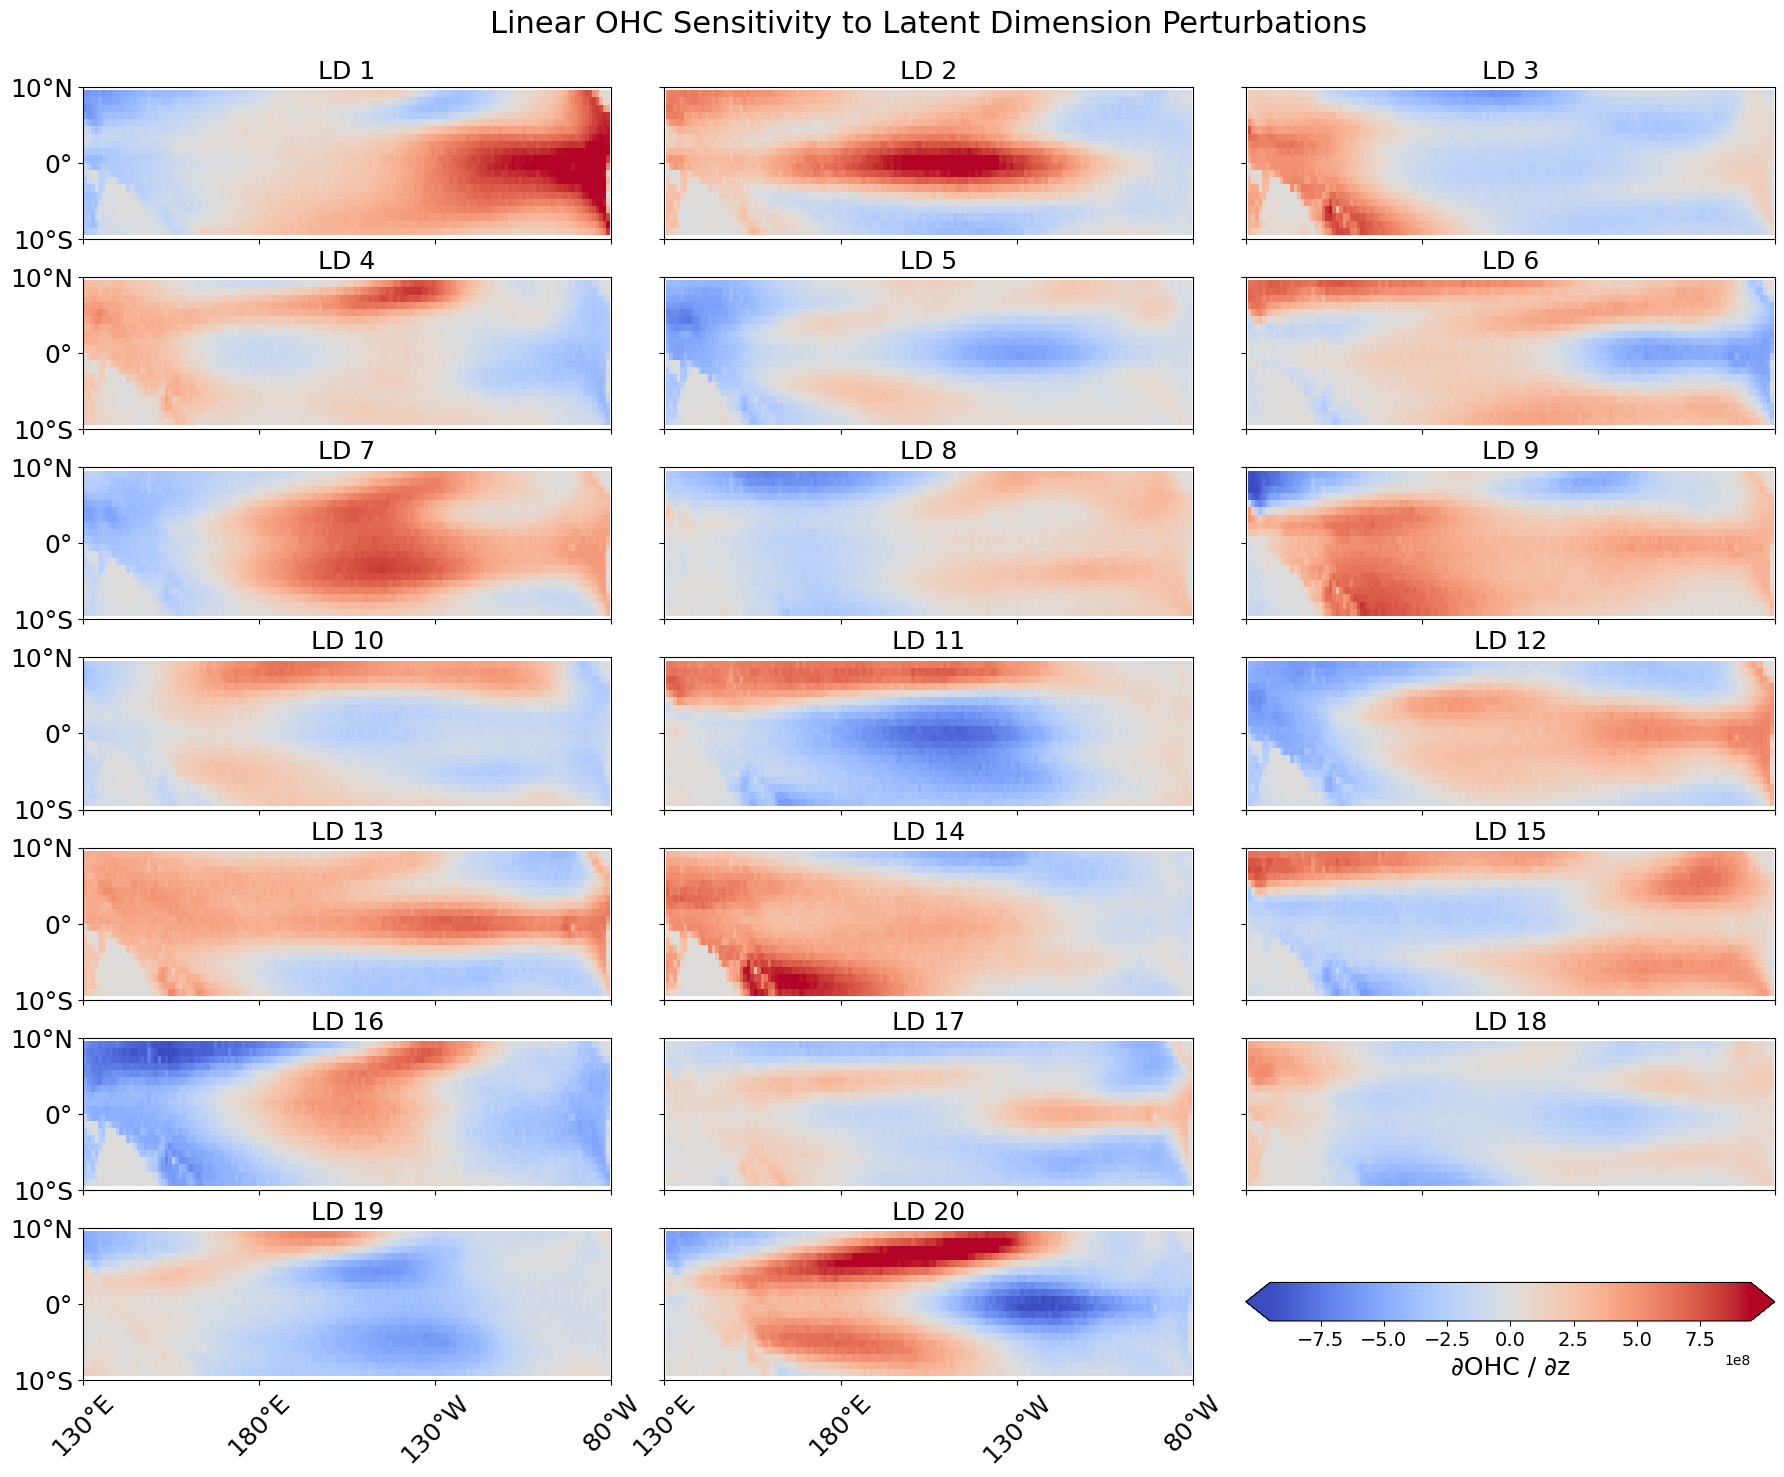

In [40]:
plot_ohc_slope_maps(slope_maps_ohc, lon=ocn_lon, lat=ocn_lat)

## olr slope maps

In [41]:
def generate_olr_slope_maps(
    decoder_model,
    scaler_olr,
    olr_yindx,
    olr_xindx,
    sweep_range,
    latent_dim,
    n_points
):

    # atmosphere grid size
    ny, nx = 22, 121
    slope_maps = np.zeros((latent_dim, ny, nx))

    for ld in range(latent_dim):
        print(f"Computing OLR slope for latent dimension {ld}")

        # idealized latent traversal
        # # filled with zero vector to isloate each dimensions
        latent_sweep = np.zeros((n_points, latent_dim))
        latent_sweep[:, ld] = sweep_range

        # only interested in olr here
        _, _, recon_olr = decoder_model.predict(latent_sweep, verbose=0)
        flat_olr = scaler_olr.inverse_transform(
            recon_olr.reshape(n_points, -1)
        )

        # reshape to grid for clarity
        olr_grid = reconstruct_grid_olr(flat_olr, olr_yindx, olr_xindx)

        # regress at each grid cell
        for y in range(ny):
            for x in range(nx):
                if np.all(np.isnan(olr_grid[:, y, x])):
                    continue
                slope, _ = np.polyfit(sweep_range, olr_grid[:, y, x], 1)
                slope_maps[ld, y, x] = slope

    return slope_maps

In [42]:
slope_maps_olr = generate_olr_slope_maps(decoder_model=decoder_model,
                        scaler_olr=scaler_olr,
                        olr_yindx=olr_yindx,
                        olr_xindx=olr_xindx,
                        sweep_range=sweep_range,
                        latent_dim=latent_dim,
                        n_points=n_points
                       )

Computing OLR slope for latent dimension 0
Computing OLR slope for latent dimension 1
Computing OLR slope for latent dimension 2
Computing OLR slope for latent dimension 3
Computing OLR slope for latent dimension 4
Computing OLR slope for latent dimension 5
Computing OLR slope for latent dimension 6
Computing OLR slope for latent dimension 7
Computing OLR slope for latent dimension 8
Computing OLR slope for latent dimension 9
Computing OLR slope for latent dimension 10
Computing OLR slope for latent dimension 11
Computing OLR slope for latent dimension 12
Computing OLR slope for latent dimension 13
Computing OLR slope for latent dimension 14
Computing OLR slope for latent dimension 15
Computing OLR slope for latent dimension 16
Computing OLR slope for latent dimension 17
Computing OLR slope for latent dimension 18
Computing OLR slope for latent dimension 19


In [43]:
slope_maps_olr.shape

(20, 22, 121)

In [44]:
def plot_olr_slope_maps(slope_maps_olr, lon, lat):

    n_ld = slope_maps_olr.shape[0]
    ncols = 3
    nrows = int(np.ceil(n_ld / ncols))

    fig, axs = plt.subplots(
        nrows, ncols,
        figsize=(6 * ncols, 2.2 * nrows),
        sharex=True, sharey=True
    )
    axs = axs.flatten()

    vmax = 18
    vmin = -18
    extent = [lon.min(), lon.max(), lat.min(), lat.max()]

    # Define a subset of longitude ticks you want displayed
    #tick_lons = np.array([130, 160, 190, 220, 250, 280])
    tick_lons = np.array([130, 180, 230, 280])
    tick_labels_lon = []
    for lon_val in tick_lons:
        if lon_val <= 180:
            tick_labels_lon.append(f"{int(lon_val)}°E")
        else:
            tick_labels_lon.append(f"{360 - int(lon_val)}°W")  # 280 → 80°W

    # Define a subset of latitude ticks
    lat_ticks = np.array([-10, 0, 10])  # e.g., -10, -5, 0, 5, 10
    tick_labels_lat = []
    for lat_val in lat_ticks:
        if lat_val < 0:
            tick_labels_lat.append(f"{abs(lat_val)}°S")
        elif lat_val > 0:
            tick_labels_lat.append(f"{lat_val}°N")
        else:
            tick_labels_lat.append("0°")

    for ld in range(n_ld):
        ax = axs[ld]
        im = ax.imshow(
            slope_maps_olr[ld],
            origin='lower',
            extent=extent,
            cmap='BrBG_r',
            vmin=vmin,
            vmax=vmax,
            aspect='auto'
        )
        ax.set_title(f'LD {ld+1}', fontsize=18)
        ax.tick_params(axis='both', labelsize=18)
        ax.set_xticklabels(tick_labels_lon, ha='center', rotation=45)  # rotate 45° and align right

        # Set the subset of ticks and custom labels
        ax.set_xticks(tick_lons)
        ax.set_xticklabels(tick_labels_lon)
        ax.set_yticks(lat_ticks)
        ax.set_yticklabels(tick_labels_lat)

    # turn off unused axes
    for ax in axs[n_ld:]:
        ax.axis('off')

    #adjust spacing
    plt.subplots_adjust(
        left=0.03, right=0.97, top=0.92, bottom=0.08,
        wspace=0.1, hspace=0.25
    )

    # --- Horizontal colorbar under LD17 ---
    ax_ld17 = axs[17]  # LD17
    pos = ax_ld17.get_position()  # Bbox in figure coordinates
    cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.085, pos.width, 0.025])  # slightly below
    cbar = fig.colorbar(im,
                        cax=cbar_ax,
                        orientation='horizontal',
                        extend='both',
                        shrink=0.8)
    cbar.set_label('∂OLR / ∂z', fontsize=18)
    cbar.ax.tick_params(labelsize=14)


    fig.suptitle(
        'Linear OLR Sensitivity to Latent Dimension Perturbations',
        fontsize=22,
        y=0.97
    )
    #plt.savefig('olr_sensitivity_0305.pdf', bbox_inches='tight')

    plt.show()

/glade/derecho/scratch/ewisinski/tmp/ipykernel_85128/4071100725.py:52: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(tick_labels_lon, ha='center', rotation=45)  # rotate 45° and align right


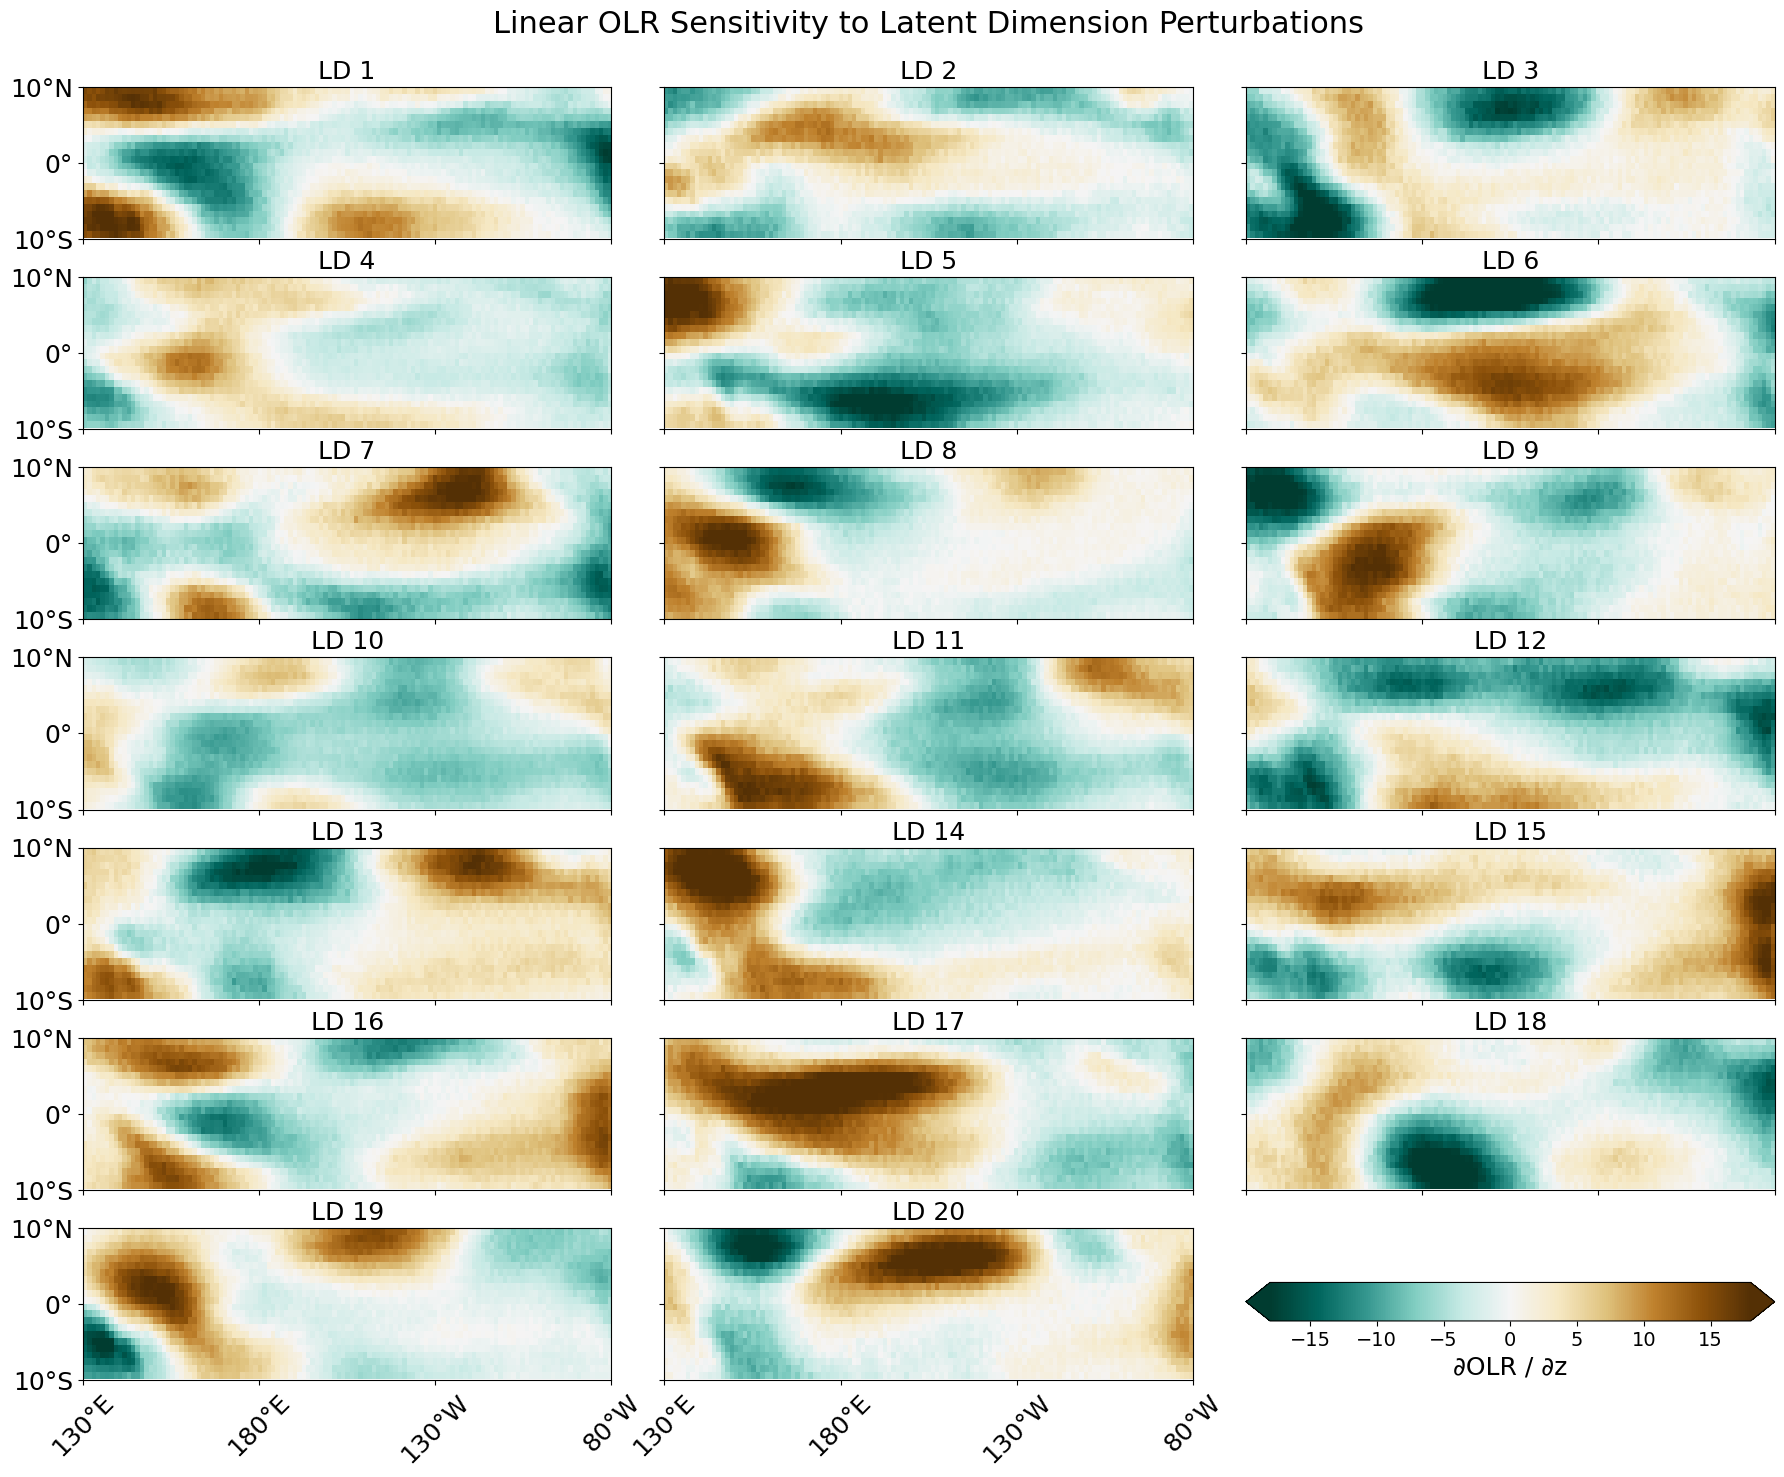

In [45]:
plot_olr_slope_maps(slope_maps_olr, lon=atm_lon, lat=atm_lat)